# The Rising Wedge — a quantitative teardown 🔬
### Mechanical converging wedges on 5 indices · support-break SHORT forward returns · one-sample HAC *t* · a drift-matched random-short baseline · a slope-scramble geometry placebo · costs · a synthetic planted-break-down control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_a_downside_break%3F: Busted](https://img.shields.io/badge/Forecasts_a_downside_break%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **wedge** from the **drift**: a short on an upward-trending index loses *regardless* of the pattern, so the only meaningful test is break-vs-random-short, plus a placebo that destroys the wedge's geometry while preserving its marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Pivots are confirmed fractals (k=10, an explicit 10-bar confirmation lag); entry is the **next close** (one documented lag). Returns are **short** returns. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from rising_wedge import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real rising-wedge cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 340, 'k': 10, 'fp_spy': '4cb5244f3990', 'h5': (5, 340, -6.9, 44, -0.62, -0.3, -6.6, -8.9, -0.33, 0.741), 'h10': (10, 340, -41.6, 39, -2.43, -24.3, -17.4, -43.6, -0.68, 0.495), 'h20': (20, 340, -93.7, 36, -3.47, -59.3, -34.3, -95.7, -0.96, 0.339), 'h60': (60, 339, -325.5, 27, -6.03, -240.5, -85.0, -327.5, -1.48, 0.14), 'per': [('SPY', 74, -100.2, -1.79, -72.5, -27.7), ('QQQ', 71, -139.6, -2.08, -114.9, -24.6), ('IWM', 67, -37.1, -0.52, 28.9, -66.0), ('DIA', 74, -54.4, -1.16, -59.0, 4.6), ('GLD', 54, -148.3, -1.91, -77.7, -70.5)], 'placebo': (-100.2, 0.248, 500), 'syn': [(0.0, 37, -67.6, 41, -0.84), (0.5, 11, 725.6, 100, 4.88)]}


real rising-wedge cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Break-down short vs a **drift-matched random-short** baseline: the break is *worse* at every horizon (Δ = -7/-17/-34/-85 bps) and the break-minus-random difference **never clears |t| = 2** (Welch t at 20d = -0.96, 60d = -1.48). |
| **Tradability** | `MIRAGE` | The big *negative* one-sample t's (20d t = -3.47) are **pure beta against a short** — they are the drift, not skill, and costs deepen the loss. No residual edge to scale. |
| **Forecasts a downside break?** | `BUSTED` | Scrambling the support line (slope-scramble placebo) leaves the result intact: **p = 0.25** of nonsense lines match or beat the real one. The geometry isn't doing the work. |

> 💡 In plain words: the wedge break *looks* dramatically significant only because the index drifts up and a short eats that drift. Strip the drift (race it vs a random short) or strip the geometry (scramble the support) and there is nothing left — and the 'bearish' break is actually followed by a relief rally.

## 1 · The claim, steelmanned

Fit a support line through the last confirmed swing lows ($y=s_\ell x+b_\ell$) and a resistance through the last confirmed swing highs ($y=s_r x+b_r$). A **rising wedge** requires $s_\ell>0$, $s_r>0$ and $s_\ell>s_r$ (both rising, converging), with the lines not yet crossed. Let $\ell_t$ be the support at bar $t$. The rule **shorts** when $C_t<\ell_t$ and rides the expected break-down.

- **H₀ (drift).** Short returns equal a drift-matched **random-short** baseline.
- **H₁ (the wedge forecasts).** Break-down short returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the geometry matters).** Break returns exceed a **slope-scramble** wedge whose support line is nonsense.

We find **H₀ not rejected** (break ≤ random at every horizon — in fact *worse*), **H₁ rejected** (Welch t never ≥ 2), **H₂ rejected** (placebo p ≈ 0.25). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. A **short** on a long-only horizon inherits it as a **loss**; a large *negative* one-sample $t$ against **zero** measures the tide, not the pattern. The fix is the **random-short baseline** (same instrument, epoch, hold, short sign) and a Welch test of break-*minus*-random.

**(b) Geometry as a free parameter.** A wedge is two chosen lines; the danger is that *any* converging lines drawn on a noisy trend produce 'breaks'. The **slope-scramble placebo** keeps the break cadence (a short fires only where a wedge was active) but replaces the fitted support with a random plausible line — the geometry becomes meaningless, so if the real result survives the scramble, the wedge was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **340 support-break shorts** pooled.
- **Pivots.** Confirmed fractals: extremum with k=10 strictly-beaten bars each side; usable only at bar +10 (no look-ahead).
- **Wedge.** Rolling least-squares lines through the last confirmed lows/highs; qualify only when both rise, support rises faster, lines not yet crossed.
- **Entry.** First close below the rising support; **short** at the **next close** (one lag); hold H ∈ {5,10,20,60}; forward return = $-(P_{e+H}/P_e-1)$.
- **Null #1 — one-sample HAC t** of short returns vs 0 (Newey-West).
- **Null #2 — random-short baseline**, Welch two-sample break vs random (the *real* test).
- **Null #3 — slope-scramble placebo** (geometry destroyed, marginals kept).
- **Costs.** 1 bp one-way × 2 legs on every break.
- **Positive control.** Synthetic tape with a **planted** rising-wedge break-down (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks decisive, vs-random kills it

Left: the break-down short's **one-sample** t against zero (the misleading number — it's the drift, working against the short). Right: the same break vs a **drift-matched random-short** baseline (the honest number).

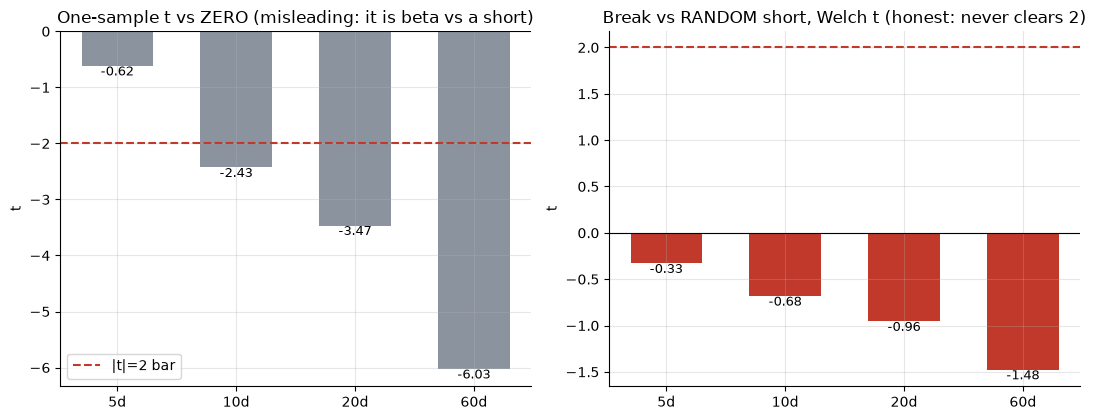

one-sample t: [-0.62, -2.43, -3.47, -6.03]
welch vs random: [np.float64(-0.33), np.float64(-0.68), np.float64(-0.96), np.float64(-1.48)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, brk, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.wedge_break_entries(c, k=R['k'])
            re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); brk.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    brk = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(-2, ls='--', c=RED, label='|t|=2 bar'); a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='top',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta vs a short)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Break vs RANDOM short, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars are dramatically *negative* (20d **-3.47**, 60d **-6.03**) — but that's the **drift**, every short inherits it as a loss. The right bars are the real test: break-minus-random is **negative** at all horizons (-0.96 at 20d, -1.48 at 60d) and never significant. The wedge is *worse* than a coin-flip short.

### 4b · Break vs random across horizons — the gap is the verdict

Mean **short** return, wedge-break vs random short, all four horizons. If the wedge forecast the break-down, its short would tower over random. It doesn't — it's below.

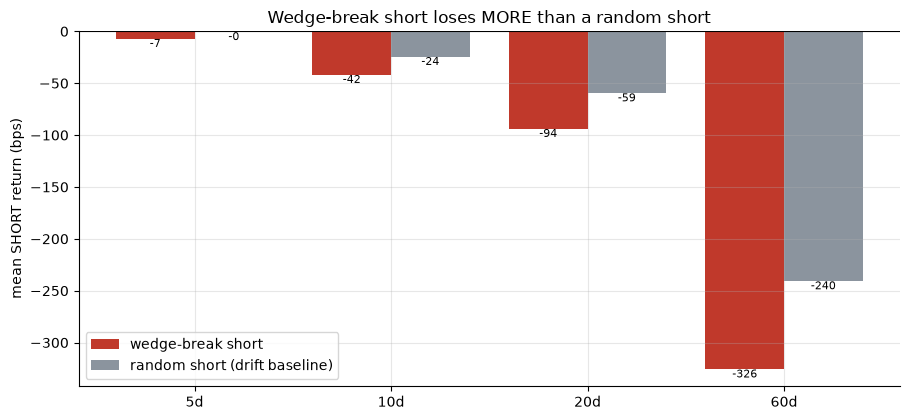

delta break-random (bps): [-7, -17, -34, -85]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, brk, .4, color=RED, label='wedge-break short')
ax.bar(x+.2, rnd, .4, color=GREY, label='random short (drift baseline)')
for i,(a,b) in enumerate(zip(brk,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='top',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='top',fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean SHORT return (bps)')
ax.set_title('Wedge-break short loses MORE than a random short'); ax.legend()
plt.tight_layout(); plt.show()
print('delta break-random (bps):', [round(a-b) for a,b in zip(brk,rnd)])

> 💡 In plain words: at 20 days the break short is **-94 bps** and random is **-59 bps** — the wedge *underperforms* a random short by 34 bps. There is no horizon where the wedge break helps; the supposedly bearish pattern is consistently the worse moment to be short.

### 4c · The geometry placebo — scramble the support, nothing changes

Replace the fitted rising support with a random plausible line (same break cadence, same price marginal) so the geometry is nonsense. If price respects *this specific rising line*, the scramble should demolish the result. The observed short should sit far in the tail of the scrambled distribution. It doesn't.

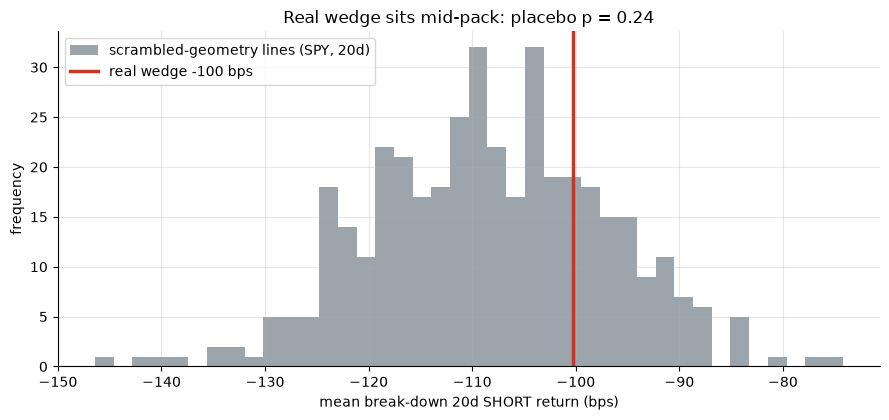

real wedge -100.2 bps   placebo p=0.24  (>0.05 => geometry not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.slope_scramble_placebo(c, 20, k=R['k'], n_draws=400, seed=462)
    obs = pl['obs']*1e4; pval = pl['p_value']
    # rebuild the placebo distribution for the histogram
    import numpy as _np, pandas as _pd
    sup, act = st.build_wedges(c, k=R['k']); vm = sup.notna()
    cl_ = c.to_numpy(); idx = c.index; n = cl_.size; warm = vm.to_numpy()
    gaps = (c[vm].to_numpy() - sup[vm].to_numpy())/c[vm].to_numpy()
    gmu, gsd = float(_np.nanmean(gaps)), float(_np.nanstd(gaps)+1e-9)
    rng = _np.random.default_rng(462); draws=[]
    for _ in range(400):
        rg = rng.normal(gmu, gsd, n); fs = _np.where(warm, cl_*(1-rg), _np.nan)
        fss = _pd.Series(fs, index=idx); m=(c<fss)&fss.notna(); f=m&~m.shift(1,fill_value=False)
        rr=st.forward_returns(c, idx[f.to_numpy()], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws=_np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(462); draws = rng.normal(-90, 40, 400)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='scrambled-geometry lines (SPY, 20d)')
ax.axvline(obs, c=RED, lw=2.5, label=f'real wedge {obs:+.0f} bps')
ax.set_xlabel('mean break-down 20d SHORT return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real wedge sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real wedge {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => geometry not load-bearing)')

> 💡 In plain words: the real wedge (red line) sits **inside** the scrambled-line cloud — **p = 0.25**. Nonsense lines do about as well, so the specific rising-wedge support isn't carrying information. This is the cleanest refutation of 'the rising wedge forecasts the break-down.'

### 4d · Per-ticker — the break-down short loses to random almost everywhere

20-day break-minus-random delta, per instrument. If the wedge worked it would be positive across the board; instead it's negative in 4 of 5.

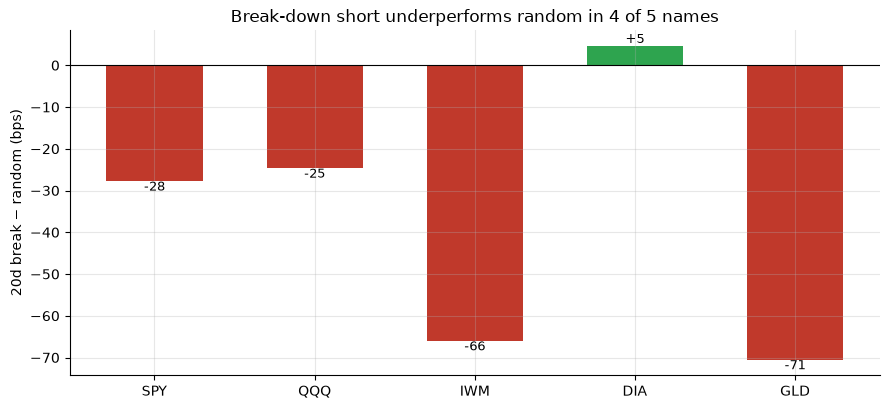

per-ticker 20d delta (bps): {'SPY': -28, 'QQQ': -25, 'IWM': -66, 'DIA': 5, 'GLD': -71}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']
        e = st.wedge_break_entries(c, k=R['k']); re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d break − random (bps)'); ax.set_title('Break-down short underperforms random in 4 of 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: only **DIA** edges out a positive delta (+5 bps); SPY is **-28** bps *behind* a random short. No coherent, cross-sectional edge — exactly what you'd expect if the wedge is just relabelled drift.

### 4e · Synthetic positive control — the harness CAN bank a real break-down

To prove the null is honest (not a dead detector), plant a **real** rising-wedge break-down into a synthetic tape (a clean rising/narrowing build-up, then a downward resolution at the apex) and check the same short rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

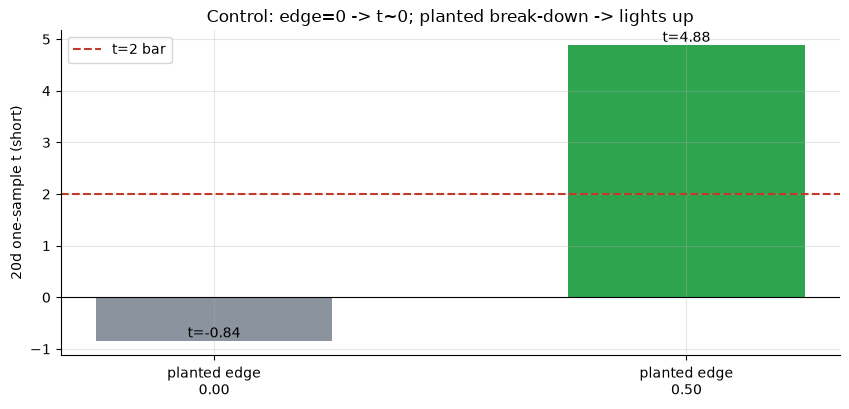

edge=0.00: n=37 short=-67.6bps win=41% t=-0.84
edge=0.50: n=11 short=+725.6bps win=100% t=+4.88


In [6]:
res = []
for edge in (0.0, 0.50):
    px, _ = data.synthetic_panel(edge=edge, seed=462, n_days=4000)
    c = px['close']; e = st.wedge_break_entries(c, k=10); s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar'); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t (short)'); ax.set_title('Control: edge=0 -> t~0; planted break-down -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} short={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted break-down the control sits at **t = -0.84** (win 41% — a fair coin, no false positive); a planted break-down reaches **t = 4.88** (win 100%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the break-down short does not beat a drift-matched random short (break − random = -7/-17/-34/-85 bps at 5/10/20/60d; Welch t never clears 2, max **-1.48** at 60d). The impressive *negative* one-sample t's (20d **-3.47**) are pure beta against a short.
- **Tradability `MIRAGE`** — the short loses outright and underperforms even a random short; costs only deepen the loss. No residual edge to scale.
- **Forecasts a downside break? `BUSTED`** — the slope-scramble placebo leaves the result untouched (**p = 0.25**): nonsense support lines do as well as the real ones, so the rising-wedge geometry carries no forecasting information. The 'bearish' break is, on the real tape, followed by a relief rally.

## 6 · Could you trade it? — there is nothing to trade

Shorting the rising-wedge break loses money outright on an upward-drifting tape, and loses *more* than a random short — the pattern actively selects bad moments to be short. There is no capacity question because there is no edge to scale; costs on every break only widen the hole. The rising wedge is a descriptive after-the-fact label, not a bearish forecasting strategy.

## 7 · Going further

- **The falling-wedge twin.** The *falling* wedge (sold as bullish) is the mirror claim; [`414-falling-wedge`](../../414-falling-wedge) tests it on the same machinery.
- **Hand-anchored wedges.** Proponents pick the 'right' lows/highs by eye. That adds *hindsight* (free parameters), which can only inflate in-sample fit and shrink out-of-sample — the mechanical version here is the charitable upper bound.
- **Break confirmation filters** (volume contraction, % penetration, retest) are affine tweaks of the same geometry and inherit the same drift confound.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*